# DDPM from scratch — the simplest version that actually works

A complete Denoising Diffusion Probabilistic Model, trained on MNIST, in one notebook.

Paper: [Ho, Jain & Abbeel (2020)](https://arxiv.org/abs/2006.11239) — *Denoising Diffusion Probabilistic Models*

Everything here follows the paper directly:

| Notebook | Paper |
|---|---|
| `q_sample` | Equation 4 |
| training loop | Algorithm 1 |
| `sample` | Algorithm 2 |
| `UNet` | Section 4, architecture |

**Before you run:** set the runtime to GPU , *Runtime → Change runtime type → T4 GPU*.


## 1. Setup

Colab already has everything we need, so there is nothing to install.

In [ ]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("device:", device)
if device == "cpu":
    print("\n*** WARNING: no GPU found. Runtime -> Change runtime type -> T4 GPU ***")

torch: 2.11.0+cu128
device: cuda


## 2. Config

These are the paper's hyperparameters. `T=1000`, betas from `1e-4` to `0.02`, Adam at `2e-4`.

`EPOCHS = 20` gives clean digits. Drop it to 3 if you just want to see it run.

In [ ]:
T          = 1000      # number of diffusion steps
BETA_START = 1e-4
BETA_END   = 0.02
EPOCHS     = 20
BATCH      = 128
LR         = 2e-4
IMG_SIZE   = 28
torch.manual_seed(0)

## 3. The forward process

The only equation that really matters is **equation 4**:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

where $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s \le t}\alpha_s$.

This lets us jump straight to *any* noise level in one line , with no loop.

In [ ]:
betas          = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas         = 1.0 - betas
abar           = torch.cumprod(alphas, dim=0)          # alpha_bar_t
sqrt_abar      = abar.sqrt()                           # weight on the image
sqrt_one_m_abar = (1.0 - abar).sqrt()                  # weight on the noise

def q_sample(x0, t, eps):
    '''Equation 4: add t steps' worth of noise to x0 in a single shot.'''
    a = sqrt_abar[t].view(-1, 1, 1, 1)
    b = sqrt_one_m_abar[t].view(-1, 1, 1, 1)
    return a * x0 + b * eps

print(f"alpha_bar[0]    = {abar[0]:.5f}   (image almost untouched)")
print(f"alpha_bar[{T-1}] = {abar[-1]:.7f} (image is gone)")

alpha_bar[0]    = 0.99990   (image almost untouched)
alpha_bar[999] = 0.0000404 (image is gone)


### Look at it

Let's actually watch an image being destroyed. This is the forward process , no neural network
involved, nothing learned.

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 515kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]


training images: 60000


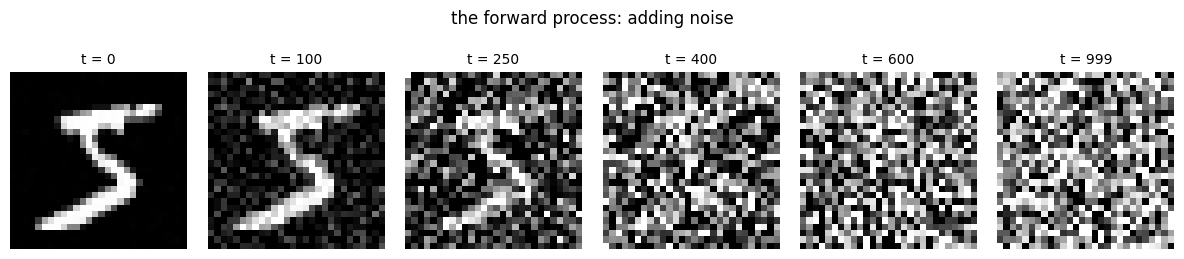

In [ ]:
tf = transforms.Compose([
    transforms.ToTensor(),                  # [0,1]
    transforms.Normalize((0.5,), (0.5,)),   # -> [-1,1], which is what the model expects
])
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=tf)
loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                    num_workers=2, drop_last=True)
print("training images:", len(train_set))

# one image, noised at increasing t
x0 = train_set[0][0].unsqueeze(0).to(device)
steps = [0, 100, 250, 400, 600, 999]
fig, axes = plt.subplots(1, len(steps), figsize=(12, 2.4))
for ax, s in zip(axes, steps):
    t = torch.tensor([s], device=device)
    xt = q_sample(x0, t, torch.randn_like(x0))
    ax.imshow(xt[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"t = {s}", fontsize=10)
    ax.axis("off")
plt.suptitle("the forward process: adding noise", y=1.06)
plt.tight_layout(); plt.savefig("forward_process.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. The network

The network's only job: **look at a noisy image and predict which noise was added to it.**

It's a small U-Net — down to 7x7, back up to 28x28, with skip connections. The one addition
compared to an ordinary U-Net is that it also has to know *which* timestep it is looking at, so
`t` is turned into a sinusoidal embedding (the same positional encoding used in Transformers) and
added inside every block.

In [ ]:
def timestep_embedding(t, dim):
    '''Sinusoidal embedding of the timestep, exactly as in the Transformer.'''
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    '''Two convs, plus the timestep embedding injected in the middle.'''
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, c_in)
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, c_out)
        self.norm2 = nn.GroupNorm(8, c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, temb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(temb))[:, :, None, None]   # <- the clock
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, base=64, t_dim=256):
        super().__init__()
        self.t_dim = t_dim
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim // 2, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim)
        )
        c1, c2, c3 = base, base * 2, base * 4          # 64, 128, 256

        self.inc   = nn.Conv2d(1, c1, 3, padding=1)
        self.rb1   = ResBlock(c1, c1, t_dim)                    # 28x28
        self.down1 = nn.Conv2d(c1, c1, 3, stride=2, padding=1)  # -> 14x14
        self.rb2   = ResBlock(c1, c2, t_dim)                    # 14x14
        self.down2 = nn.Conv2d(c2, c2, 3, stride=2, padding=1)  # -> 7x7
        self.mid1  = ResBlock(c2, c3, t_dim)                    # 7x7
        self.mid2  = ResBlock(c3, c2, t_dim)                    # 7x7
        self.up1   = ResBlock(c2 + c2, c1, t_dim)               # 14x14 (after concat)
        self.up2   = ResBlock(c1 + c1, c1, t_dim)               # 28x28 (after concat)
        self.out   = nn.Sequential(
            nn.GroupNorm(8, c1), nn.SiLU(), nn.Conv2d(c1, 1, 3, padding=1)
        )

    def forward(self, x, t):
        temb = self.t_mlp(timestep_embedding(t, self.t_dim // 2))

        h1 = self.rb1(self.inc(x), temb)          # 64  x 28 x 28
        h2 = self.rb2(self.down1(h1), temb)       # 128 x 14 x 14
        m  = self.mid1(self.down2(h2), temb)      # 256 x  7 x  7
        m  = self.mid2(m, temb)                   # 128 x  7 x  7

        u = F.interpolate(m, scale_factor=2, mode="nearest")     # 128 x 14 x 14
        u = self.up1(torch.cat([u, h2], dim=1), temb)            # 64  x 14 x 14
        u = F.interpolate(u, scale_factor=2, mode="nearest")     # 64  x 28 x 28
        u = self.up2(torch.cat([u, h1], dim=1), temb)            # 64  x 28 x 28
        return self.out(u)                                       # 1   x 28 x 28


model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.2f}M")

# shape check before we commit to training
with torch.no_grad():
    dummy = torch.randn(4, 1, IMG_SIZE, IMG_SIZE, device=device)
    dt = torch.randint(0, T, (4,), device=device)
    out_shape = model(dummy, dt).shape
    assert out_shape == dummy.shape, out_shape
print("forward pass OK:", tuple(out_shape))

parameters: 2.49M
forward pass OK: (4, 1, 28, 28)


## 5. Training — Algorithm 1

The entire loop, straight out of the paper:

1. take a real image $x_0$
2. pick a random timestep $t$
3. draw noise $\epsilon$
4. build $x_t$ with equation 4
5. minimise $\|\epsilon - \epsilon_\theta(x_t, t)\|^2$

No discriminator, no adversarial game. One mean squared error.

epoch   1/20  loss 0.0710  (36s)
epoch   2/20  loss 0.0342  (37s)
epoch   3/20  loss 0.0306  (38s)
epoch   4/20  loss 0.0279  (38s)
epoch   5/20  loss 0.0268  (37s)
epoch   6/20  loss 0.0259  (38s)
epoch   7/20  loss 0.0257  (38s)
epoch   8/20  loss 0.0253  (38s)
epoch   9/20  loss 0.0248  (38s)
epoch  10/20  loss 0.0244  (38s)
epoch  11/20  loss 0.0241  (38s)
epoch  12/20  loss 0.0241  (38s)
epoch  13/20  loss 0.0237  (38s)
epoch  14/20  loss 0.0236  (38s)
epoch  15/20  loss 0.0236  (38s)
epoch  16/20  loss 0.0234  (38s)
epoch  17/20  loss 0.0231  (38s)
epoch  18/20  loss 0.0230  (38s)
epoch  19/20  loss 0.0230  (38s)
epoch  20/20  loss 0.0231  (38s)


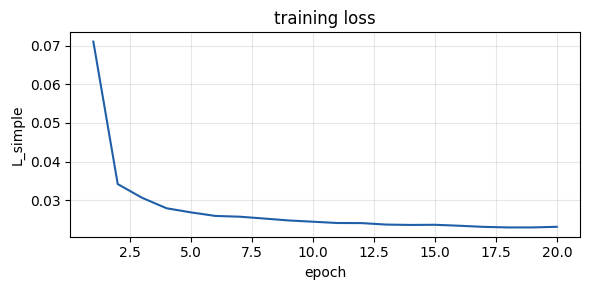

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    t0, running, seen = time.time(), 0.0, 0
    for x0, _ in loader:
        x0 = x0.to(device, non_blocking=True)

        t   = torch.randint(0, T, (x0.size(0),), device=device)   # random timestep
        eps = torch.randn_like(x0)                                # the label
        xt  = q_sample(x0, t, eps)                                # equation 4

        loss = F.mse_loss(model(xt, t), eps)                      # L_simple

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        running += loss.item() * x0.size(0)
        seen += x0.size(0)

    epoch_loss = running / seen
    losses.append(epoch_loss)
    print(f"epoch {epoch:3d}/{EPOCHS}  loss {epoch_loss:.4f}  ({time.time()-t0:.0f}s)")

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses) + 1), losses, color="#1F5FA8")
plt.xlabel("epoch"); plt.ylabel("L_simple"); plt.title("training loss")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("loss.png", dpi=130); plt.show()

## 6. Sampling — Algorithm 2

Start from pure noise and walk backwards. At each step: predict the noise, subtract a bit of it,
rescale, then **add a little noise back in**.

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,
\epsilon_\theta(x_t,t)\Big) + \sigma_t z$$

That last term surprises people. Without it, every sample collapses to the same blurry average —
the randomness is what makes the outputs diverse.

sampled 64 images in 14s (1000 network calls)


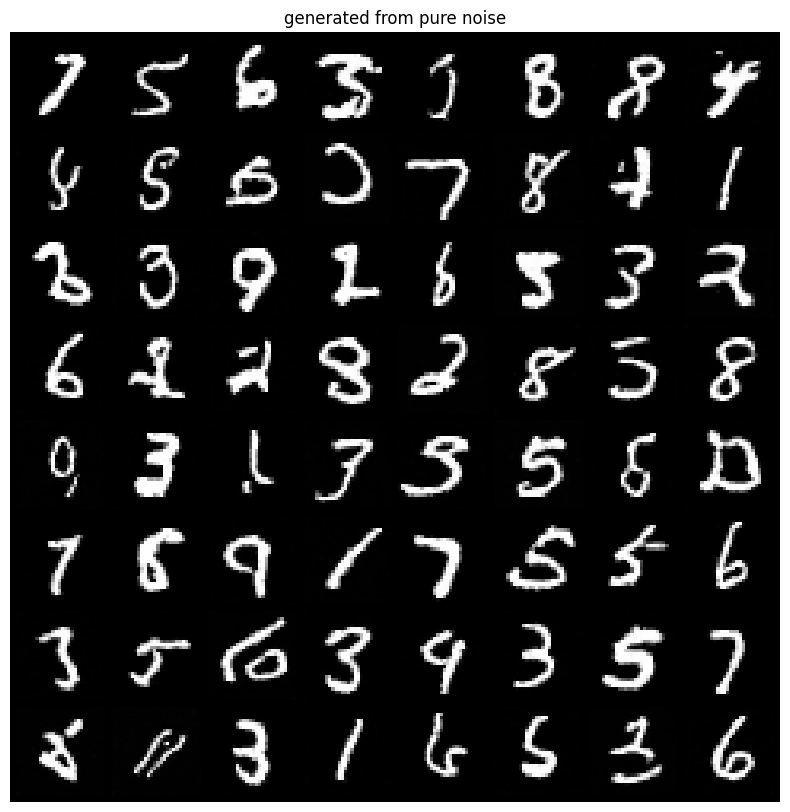

In [ ]:
@torch.no_grad()
def sample(n, keep_every=None):
    '''Algorithm 2. Returns final images, and optionally the denoising trajectory.'''
    model.eval()
    x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=device)   # pure static
    traj = []
    for i in reversed(range(T)):                               # t = T-1 ... 0
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps_hat = model(x, t)

        mean = (x - betas[i] / sqrt_one_m_abar[i] * eps_hat) / alphas[i].sqrt()
        if i > 0:
            x = mean + betas[i].sqrt() * torch.randn_like(x)    # add a little noise back
        else:
            x = mean                                           # last step is deterministic

        if keep_every and (i % keep_every == 0 or i == 0):
            traj.append(x.clone())
    model.train()
    return x, traj


def show(imgs, title, fname, nrow=8):
    imgs = (imgs.clamp(-1, 1) + 1) / 2                         # [-1,1] -> [0,1]
    grid = make_grid(imgs.cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(nrow, imgs.size(0) / nrow + 0.6))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.title(title); plt.axis("off"); plt.tight_layout()
    plt.savefig(fname, dpi=130, bbox_inches="tight"); plt.show()


t0 = time.time()
imgs, traj = sample(64, keep_every=100)
print(f"sampled 64 images in {time.time()-t0:.0f}s ({T} network calls)")
show(imgs, "generated from pure noise", "samples.png")

### Watch one digit appear

Left is pure noise, right is the finished sample. Same network at every step — the only thing
that changes is `t`.

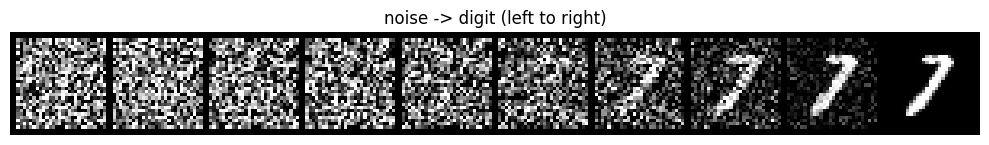

In [ ]:
steps = torch.cat([tr[:1] for tr in traj], dim=0)   # one digit's trajectory
show(steps, "noise -> digit (left to right)", "trajectory.png", nrow=len(steps))

## 7. Things to try

- **`EPOCHS = 60`** — noticeably sharper digits.
- **Fewer sampling steps.** Try `for i in reversed(range(0, T, 10))` — it breaks, and *why* it
  breaks is exactly the problem DDIM was written to solve.
- **Remove the noise injection.** Delete the `+ betas[i].sqrt() * ...` term and sample again.
  Every image collapses toward the same grey blob.
- **Fashion-MNIST.** Swap `datasets.MNIST` for `datasets.FashionMNIST`. Nothing else changes.
- **Predict the image instead of the noise.** Train against `x0` rather than `eps` and watch the
  quality drop — that is the reparameterization from equation 11 earning its keep.